# Airbnb Dynamic Pricing Recommendation Engine

## Project Overview

The Airbnb Dynamic Pricing Recommendation Engine is designed to help Airbnb hosts determine an optimal nightly price for their listings using historical Airbnb data.

The project analyzes listing characteristics such as location, room type, availability, minimum nights, and customer reviews to understand pricing patterns and build a machine learning model capable of recommending competitive prices.

### Objectives

- Understand the Airbnb dataset
- Perform data cleaning and quality assessment
- Explore factors affecting listing prices
- Engineer meaningful features
- Build a machine learning model for price prediction
- Generate dynamic pricing recommendations
- Visualize business insights using Power BI

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Excel
- Power BI

In [51]:
# ===========================================
# Import Required Libraries
# ===========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

# Load the Dataset

Load the Airbnb dataset into a Pandas DataFrame for analysis.

In [52]:
df = pd.read_excel("CLEANED_DATASET.xlsx" , sheet_name="Cleaned_Data")

# Preview the Dataset

Display the first, last, and random records to verify that the dataset has been loaded correctly.

In [53]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [54]:
df.sample()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
32840,25870315,Beautiful peninsula to stay,93339410,Ramon,Queens,Bayswater,40.60628,-73.76019,Entire home/apt,105,4,8,2018-10-10,0.7,1,222


# Dataset Overview

Understand the dimensions and structure of the dataset before beginning the analysis.

In [55]:
print("Dataset Shape :", df.shape)

Dataset Shape : (48895, 16)


In [56]:
rows, columns = df.shape

print("Total Rows :", rows)
print("Total Columns :", columns)

Total Rows : 48895
Total Columns : 16


In [57]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48869 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48873 non-null  object        
 4   neighbourhood_group             48895 non-null  str           
 5   neighbourhood                   48895 non-null  str           
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  str           
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  number_of_rev

In [59]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


In [60]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,48895.0,19017143.23618,2539.0,9471945.0,19677284.0,29152178.5,36487245.0,10983108.38561
host_id,48895.0,67620010.64661,2438.0,7822033.0,30793816.0,107434423.0,274321313.0,78610967.032667
latitude,48895.0,40.728949,40.49979,40.6901,40.72307,40.763115,40.91306,0.05453
longitude,48895.0,-73.95217,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299,0.046157
price,48895.0,152.720687,0.0,69.0,106.0,175.0,10000.0,240.15417
minimum_nights,48895.0,7.029962,1.0,1.0,3.0,5.0,1250.0,20.51055
number_of_reviews,48895.0,23.274466,0.0,1.0,5.0,24.0,629.0,44.550582
last_review,38843,2018-10-04 01:47:23.910099,2011-03-28 00:00:00,2018-07-08 00:00:00,2019-05-19 00:00:00,2019-06-23 00:00:00,2019-07-08 00:00:00,NaN
reviews_per_month,38843.0,1.373221,0.01,0.19,0.72,2.02,58.5,1.680442
calculated_host_listings_count,48895.0,7.143982,1.0,1.0,1.0,2.0,327.0,32.952519


In [61]:
df.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                          str
neighbourhood                                str
latitude                                 float64
longitude                                float64
room_type                                    str
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

# Missing Values

Identify the number and percentage of missing values in each column.

In [62]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round((df.isnull().sum()/len(df))*100,2)
})

missing.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage (%)
last_review,10052,20.56
reviews_per_month,10052,20.56
name,26,0.05
host_name,22,0.04
neighbourhood_group,0,0.00
neighbourhood,0,0.00
id,0,0.00
host_id,0,0.00
longitude,0,0.00
latitude,0,0.00


In [63]:
# handling missing values
df["reviews_per_month"] = df["reviews_per_month"].fillna("not yet reviewed")

In [64]:
# validating
print( "missing values in reviews_per_month : " , df["reviews_per_month"].isnull().sum())

missing values in reviews_per_month :  0


# Duplicate Record Analysis

Check whether duplicate records exist in the dataset.

In [65]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


#  Swapping Rows analysis

In [66]:
# Find rows where 'id' is not numeric
# 1. Convert 'id' to object type so it can hold names temporarily
df["id"] = df["id"].astype(object)

# 2. Find rows where 'id' is not numeric
mask = pd.to_numeric(df["id"], errors="coerce").isna()
mask.head(200)

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Name: id, Length: 200, dtype: bool

In [67]:
# 3. Swap the columns safely
df.loc[mask, ["id", "name"]] = df.loc[mask, ["name", "id"]].to_numpy()

# 4. Optional: Clean up and convert 'id' back to numeric if possible
df["id"] = pd.to_numeric(df["id"], errors="coerce")


# Date Conversion

Convert the **last_review** column into datetime format for future analysis.

In [68]:
df["last_review"] = pd.to_datetime(df["last_review"])

In [69]:
df["last_review"].head()

0   2018-10-19
1   2019-05-21
2          NaT
3   2019-07-05
4   2018-11-19
Name: last_review, dtype: datetime64[us]

# Price Validation

Verify the integrity of the target variable by checking its statistical summary and identifying invalid values.

In [70]:
df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [71]:
print("Minimum Price :", df["price"].min())
print("Maximum Price :", df["price"].max())
print("Average Price :", round(df["price"].mean(),2))
print("Median Price :", df["price"].median())

Minimum Price : 0
Maximum Price : 10000
Average Price : 152.72
Median Price : 106.0


# Average Price by Borough

In [72]:
avg_price_borough = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)

avg_price_borough

neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

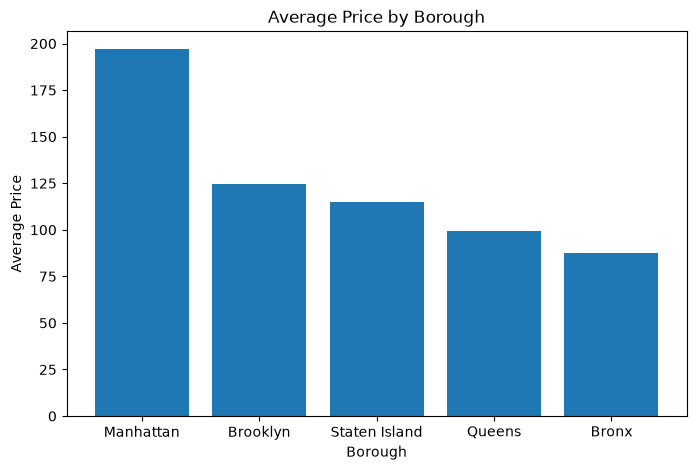

In [73]:
plt.figure(figsize=(8,5))

plt.bar(avg_price_borough.index,
        avg_price_borough.values)

plt.title("Average Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Price")

plt.show()

### Insight

Compare the average nightly prices across different boroughs to identify premium locations.

### Listings by Borough

In [74]:
borough_listings = df.groupby("neighbourhood_group")["id"].count().sort_values(ascending=False)
borough_listings

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: id, dtype: int64

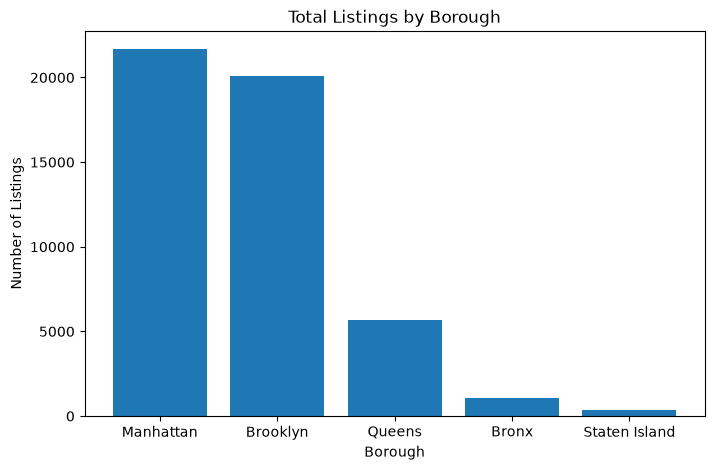

In [75]:
plt.figure(figsize=(8,5))

plt.bar(borough_listings.index,
        borough_listings.values)

plt.title("Total Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")

plt.show()

### Insight

This analysis highlights which boroughs have the highest concentration of Airbnb listings.

#  Reviews by Borough

In [76]:
Reviews_borough = df.groupby("neighbourhood_group")["number_of_reviews"].sum().sort_values(ascending=False)
Reviews_borough

neighbourhood_group
Brooklyn         486574
Manhattan        454569
Queens           156950
Bronx             28371
Staten Island     11541
Name: number_of_reviews, dtype: int64

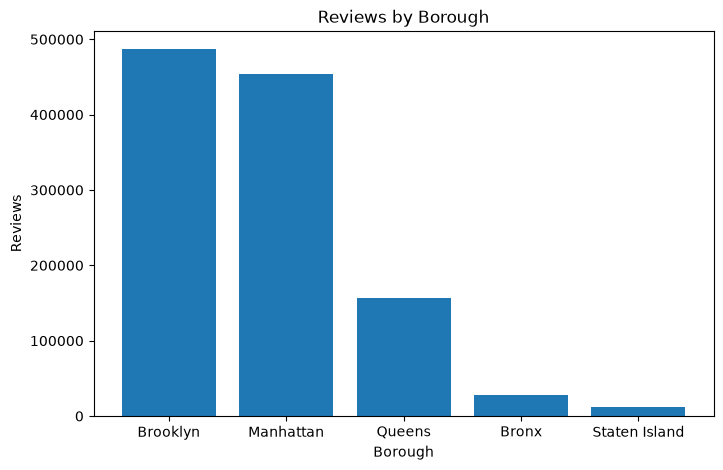

In [77]:
plt.figure(figsize=(8,5))

plt.bar(Reviews_borough.index,
        Reviews_borough.values)

plt.title("Reviews by Borough")
plt.xlabel("Borough")
plt.ylabel("Reviews")

plt.show()

# Average Availability by Borough

In [78]:
availability_borough = df.groupby("neighbourhood_group")["availability_365"].mean().sort_values(ascending=False)
availability_borough

neighbourhood_group
Staten Island    199.678284
Bronx            165.758937
Queens           144.451818
Manhattan        111.979410
Brooklyn         100.232292
Name: availability_365, dtype: float64

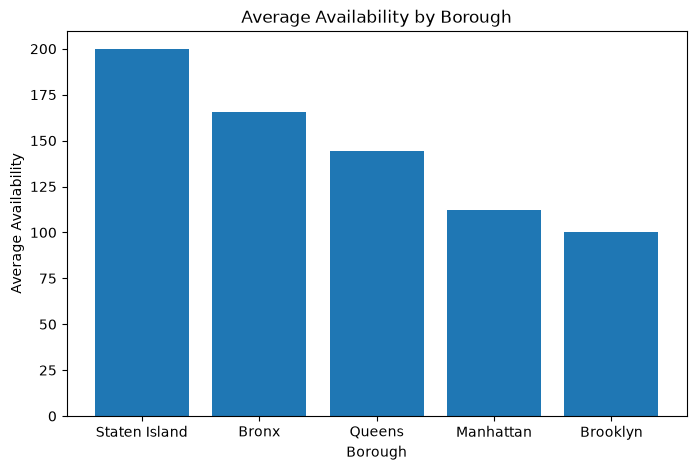

In [79]:
plt.figure(figsize=(8,5))

plt.bar(availability_borough.index,
        availability_borough.values)

plt.title("Average Availability by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Availability")

plt.show()

### Insight

Comparing availability across boroughs helps identify areas with higher listing activity throughout the year.

# Average Price by Room Type

In [80]:
room_price = df.groupby("room_type")["price"].mean().sort_values(ascending=False)

room_price

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

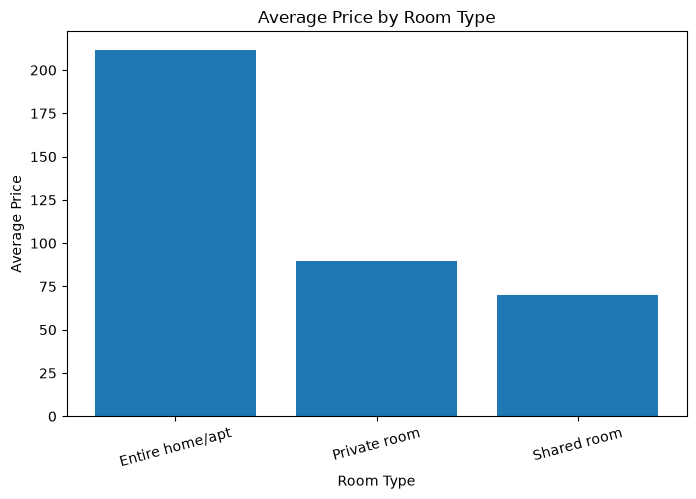

In [81]:
plt.figure(figsize=(8,5))

plt.bar(room_price.index,
        room_price.values)

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")

plt.xticks(rotation=15)

plt.show()

### Insight

Different room types have different pricing structures. This comparison identifies the most expensive accommodation type.

# Room Type Distribution

In [82]:
room_counts = df["room_type"].value_counts()

room_counts

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

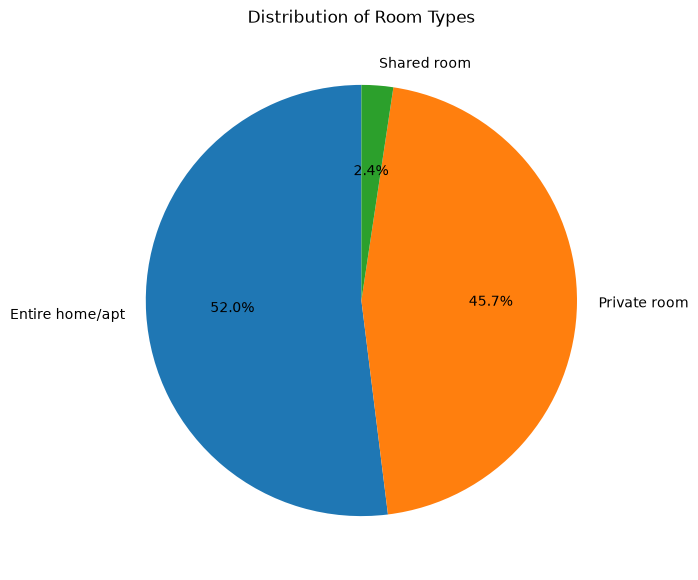

In [83]:
plt.figure(figsize=(7,7))

plt.pie(room_counts.values,
        labels=room_counts.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Distribution of Room Types")

plt.show()

### Insight

This chart shows the proportion of each room type available on Airbnb.

# Top 10 Most Expensive Neighborhoods

In [84]:
top_neighbourhoods = df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)

top_neighbourhoods

neighbourhood
Fort Wadsworth       800.000000
Woodrow              700.000000
Tribeca              490.638418
Sea Gate             487.857143
Riverdale            442.090909
Prince's Bay         409.500000
Battery Park City    367.557143
Flatiron District    341.925000
Randall Manor        336.000000
NoHo                 295.717949
Name: price, dtype: float64

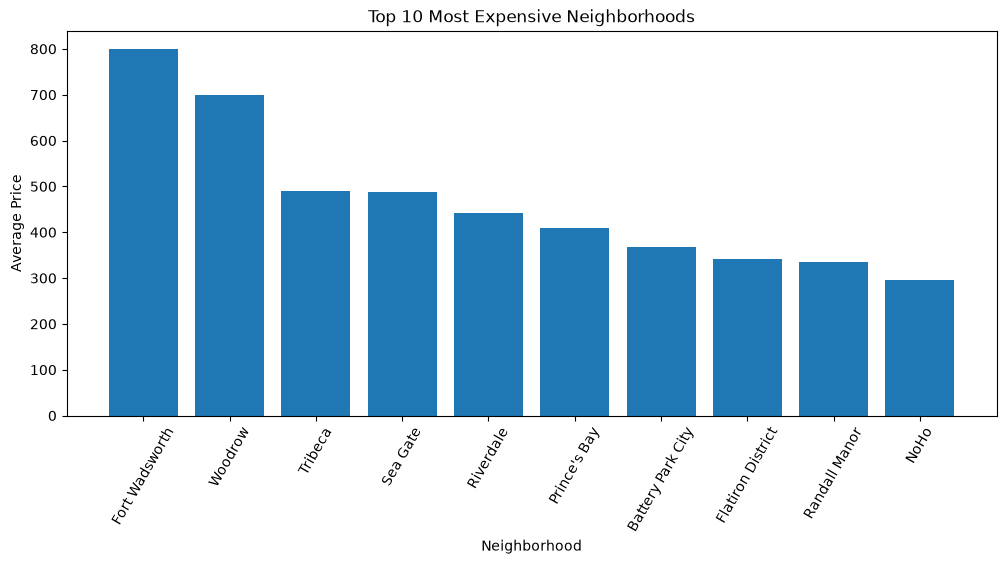

In [85]:
plt.figure(figsize=(12,5))

plt.bar(top_neighbourhoods.index,
        top_neighbourhoods.values)

plt.title("Top 10 Most Expensive Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")

plt.xticks(rotation=60)

plt.show()

### Insight

Neighborhood-level analysis provides more detailed pricing information than borough-level analysis.

# Availability Distribution

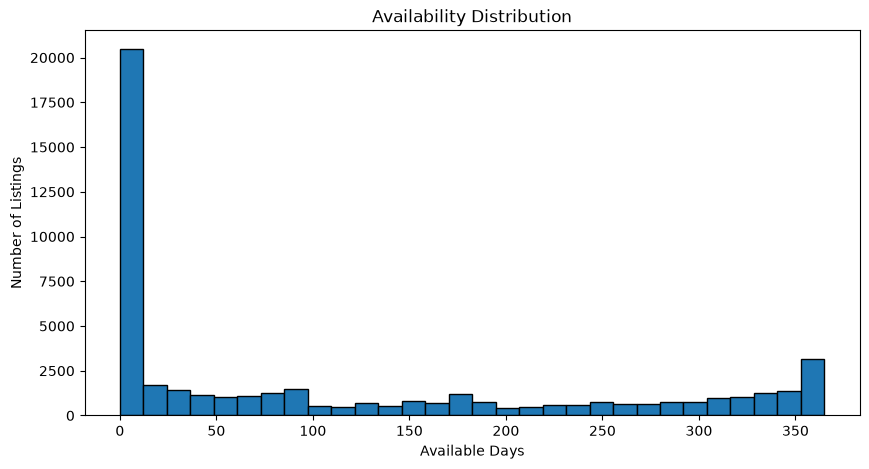

In [86]:
plt.figure(figsize=(10,5))

plt.hist(df["availability_365"],
         bins=30,
         edgecolor="black")

plt.title("Availability Distribution")
plt.xlabel("Available Days")
plt.ylabel("Number of Listings")

plt.show()

### Insight

Availability patterns may indicate occupancy levels and pricing opportunities.

# Correlation Analysis

In [87]:
correlation = df.corr(numeric_only=True)

correlation

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
id,1.000000,0.588290,-0.003125,0.090908,0.010619,-0.013224,-0.319760,0.133272,0.085468
host_id,0.588290,1.000000,0.020224,0.127055,0.015309,-0.017364,-0.140106,0.154950,0.203492
latitude,-0.003125,0.020224,1.000000,0.084788,0.033939,0.024869,-0.015389,0.019517,-0.010983
longitude,0.090908,0.127055,0.084788,1.000000,-0.150019,-0.062747,0.059094,-0.114713,0.082731
price,0.010619,0.015309,0.033939,-0.150019,1.000000,0.042799,-0.047954,0.057472,0.081829
minimum_nights,-0.013224,-0.017364,0.024869,-0.062747,0.042799,1.000000,-0.080116,0.127960,0.144303
number_of_reviews,-0.319760,-0.140106,-0.015389,0.059094,-0.047954,-0.080116,1.000000,-0.072376,0.172028
calculated_host_listings_count,0.133272,0.154950,0.019517,-0.114713,0.057472,0.127960,-0.072376,1.000000,0.225701
availability_365,0.085468,0.203492,-0.010983,0.082731,0.081829,0.144303,0.172028,0.225701,1.000000


# Key Findings

The exploratory analysis revealed several important insights:

- Airbnb prices vary significantly across boroughs and neighborhoods.
- Entire homes/apartments generally command higher prices than private or shared rooms.
- Some neighborhoods consistently have premium pricing.
- Availability differs across locations and may influence pricing.
- Review counts and host portfolio size provide useful information about listing popularity.
- These insights will guide feature engineering and improve the predictive performance of the pricing recommendation model.

# Feature Engineering

Feature engineering is the process of creating new columns from existing data to make analysis easier and improve model performance.

# Price Category

In [88]:
# Create price categories

df["price_category"] = pd.cut(
    df["price"],
    bins=[0,100,200,500,10000],
    labels=["Budget","Standard","Premium","Luxury"]
)

df[["price","price_category"]].head()

,price,price_category
0,149,Standard
1,225,Premium
2,150,Standard
3,89,Budget
4,80,Budget


In [89]:
df["price_category"].value_counts()

price_category
Budget      23917
Standard    16583
Premium      7340
Luxury       1044
Name: count, dtype: int64

# Availability Category

In [90]:
df["availability_category"] = pd.cut(
    df["availability_365"],
    bins=[-1,0,120,240,365],
    labels=["Not Available","Low","Medium","High"]
)

df[["availability_365","availability_category"]].head()

,availability_365,availability_category
0,365,High
1,355,High
2,365,High
3,194,Medium
4,0,Not Available


In [91]:
df["availability_category"].value_counts()

availability_category
Not Available    17533
Low              13060
High             11616
Medium            6686
Name: count, dtype: int64

# Review Category

In [92]:
df["review_category"] = pd.cut(
    df["number_of_reviews"],
    bins=[-1,10,50,100,1000],
    labels=["Low","Medium","High","Very High"]
)

df[["number_of_reviews","review_category"]].head()

,number_of_reviews,review_category
0,9,Low
1,45,Medium
2,0,Low
3,270,Very High
4,9,Low


In [93]:
df["review_category"].value_counts()

review_category
Low          30323
Medium       11613
High          3964
Very High     2995
Name: count, dtype: int64

# Dynamic Pricing Recommendation Engine

In [94]:
df["recommended_price"] = df.groupby(
    ["neighbourhood_group", "room_type"]
)["price"].transform("median")

In [95]:
df["price_difference"] = df["recommended_price"] - df["price"]

In [96]:
df["pricing_status"] = np.where(
    df["price"] < df["recommended_price"] * 0.90,
    "Increase Price",

    np.where(
        df["price"] > df["recommended_price"] * 1.10,
        "Consider Lowering Price",

        "Maintain Price"
    )
)

In [97]:
df[
    [
        "name",
        "neighbourhood_group",
        "room_type",
        "price",
        "recommended_price",
        "price_difference",
        "pricing_status"
    ]
].head(10)

,name,neighbourhood_group,room_type,price,recommended_price,price_difference,pricing_status
0,Clean & quiet apt home by the park,Brooklyn,Private room,149,65.0,-84.0,Consider Lowering Price
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225,191.0,-34.0,Consider Lowering Price
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150,90.0,-60.0,Consider Lowering Price
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89,145.0,56.0,Increase Price
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80,191.0,111.0,Increase Price
5,Large Cozy 1 BR Apartment In Midtown East,Manhattan,Entire home/apt,200,191.0,-9.0,Maintain Price
6,BlissArtsSpace!,Brooklyn,Private room,60,65.0,5.0,Maintain Price
7,Large Furnished Room Near B'way,Manhattan,Private room,79,90.0,11.0,Increase Price
8,Cozy Clean Guest Room - Family Apt,Manhattan,Private room,79,90.0,11.0,Increase Price
9,Cute & Cozy Lower East Side 1 bdrm,Manhattan,Entire home/apt,150,191.0,41.0,Increase Price


In [98]:
df["pricing_status"].value_counts()

pricing_status
Increase Price             20104
Consider Lowering Price    18983
Maintain Price              9808
Name: count, dtype: int64

# Save the Updated Dataset

In [99]:
df.to_excel("airbnb_EDA_Engineered.xlsx",index=False)

# Business Insights - Data Cleaning & Preparation , EDA

- The dataset was successfully prepared for analysis after validating data quality.
- Data types were verified to ensure accurate calculations and analysis.
- Duplicate records were checked to avoid biased results.
- Missing value analysis helped identify columns that required attention before modeling.
- A clean and consistent dataset improves the reliability of business insights and machine learning predictions.
- Listing prices vary significantly across neighbourhood groups, indicating that location is a major pricing factor.
- Entire homes/apartments generally have higher average prices than private or shared rooms.
- Some neighbourhoods consistently command premium prices, making them attractive for higher revenue opportunities.
- Areas with a larger number of listings indicate higher competition among hosts.
- Availability patterns differ across locations, suggesting differences in occupancy and booking demand.
    
# Business Insights - Feature Engineering

- Categorizing listing prices helps segment properties into different pricing levels for easier analysis.
- Availability categories make it easier to identify listings with high or low booking opportunities.
- Review categories help distinguish between highly popular and less active listings.
- These new variables will also enhance dashboard interactivity by providing meaningful filters and slicers in Power BI.

# Business Insights - Dynamic Pricing Recommendation Engine

The pricing recommendation analysis provides actionable insights for Airbnb hosts and marketplace managers.

### Key Business Insights

- A market-based recommended price was created using the median price of comparable listings based on neighbourhood group and room type.
- Listings priced significantly below the comparable market benchmark may have an opportunity to increase their prices and improve potential revenue.
- Listings priced significantly above the market benchmark may face increased competition and may need to reduce prices or provide additional value to justify the premium.
- Listings within the competitive pricing range can maintain their current pricing strategy.
- The comparison between current price and recommended price provides a practical method for identifying pricing gaps across the Airbnb marketplace.
- Location and room type are important factors when determining an appropriate market-based price.
- The recommendation engine converts historical Airbnb listing data into actionable pricing recommendations for individual listings.
- The results can help hosts make more informed pricing decisions instead of relying only on intuition or fixed pricing strategies.